In [1]:
# ── Celda 1: Carga ────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path("..")
df = pd.read_csv(ROOT / "data/processed/yapo_clean.csv")
print(df.shape)
print(df.dtypes)
df.head(3)


(15860, 21)
id                    int64
titulo                  str
precio_clp            int64
anio                  int64
combustible             str
transmision             str
kilometraje           int64
vendedor                str
region                  str
destacado            object
url                     str
fecha_scraping          str
fecha_publicacion       str
comuna                  str
marca                   str
modelo                  str
empresa                 str
direccion               str
tipo_vendedor           str
descripcion             str
edad_auto             int64
dtype: object


,id,titulo,precio_clp,anio,combustible,transmision,kilometraje,vendedor,region,destacado,...,fecha_scraping,fecha_publicacion,comuna,marca,modelo,empresa,direccion,tipo_vendedor,descripcion,edad_auto
0,32079793,BMW 320 IA AÑO 2010,5780000,2010,Bencina,Automática,122690,Juan Pablo HZ,Metropolitana,False,...,2026-03-05,2026-03-05,Ñuñoa,Bmw,320,Diagonal Autos,"Presidente Jose Batlle y Ordoñez 3701, Ñuñoa, ...",profesional,"BMW 320 IA 2.0 AT AÑO 2010PRECIO OCASIÓN, VEHI...",16
1,32079630,2015 Peugeot 208 ALLURE E HDI 1.6,9280000,2015,Diesel,Automática,54997,Pedro Pelayo,Metropolitana,False,...,2026-03-05,2026-03-05,La Reina,Peugeot,208,Automoviles pelayo ltda,AVDA OSSA 315 LA REINA -,profesional,UNICO DUEÑOCOPIA DE LLAVEEXCELENTE ESTADOCIERR...,11
2,32019792,Kia Frontier 2.5L 2018 Único Dueño OPORTUNIDAD,11490000,2018,Diesel,Manual,184000,MAO Autos,Metropolitana,False,...,2026-03-05,2026-03-05,San Miguel,Kia,Frontier,Mao Autos,"Av. José Joaquín Prieto 5650, San Miguel. -",profesional,Mao Autos¡Vendemos o recibimos tu vehículo en ...,8


In [2]:
# ── Celda 2: Nulos residuales ──────────────────────────────────────
# DECISIÓN: después de la limpieza no debería haber nulos en las
# columnas que usaremos como confounders en el modelo causal.
# Si los hay → registrar y decidir: imputar o eliminar fila.
nulos = df.isnull().sum().sort_values(ascending=False)
pct   = (nulos / len(df) * 100).round(2)
pd.DataFrame({"nulos": nulos, "%": pct})[nulos > 0]


,nulos,%
direccion,4377,27.60
vendedor,2310,14.56
destacado,2309,14.56
descripcion,978,6.17
titulo,31,0.20


In [ ]:
#Celda 2.5: Variable de tratamiento D ──────────────────────────────
# Una automotora es cualquier vendedor con razón social distinta a 'Particular'
df['es_automotora'] = (df['tipo_vendedor'].str.strip().str.lower() != 'particular').astype(int)

print(df['es_automotora'].value_counts())
# Verificación de overlap (requisito del DAG)
print(df.groupby('es_automotora')['precio_clp'].describe())


es_automotora
0    11503
1     4357
Name: count, dtype: int64
                 count          mean           std        min        25%  \
es_automotora                                                              
0              11503.0  9.151983e+06  6.780172e+06  1000000.0  5000000.0   
1               4357.0  1.682319e+07  1.138752e+07  1000000.0  9990000.0   

                      50%         75%          max  
es_automotora                                       
0               7700000.0  11500000.0  220000000.0  
1              13980000.0  19900000.0  159900000.0  


es_automotora
0    11503
1     4357
Name: count, dtype: int64
es_automotora
0    0.725
1    0.275
Name: proportion, dtype: float64


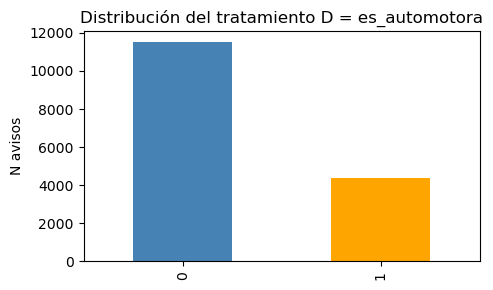

In [6]:
# ── Celda 3: Variable de tratamiento ──────────────────────────────
# DECISIÓN CRÍTICA (Positivity Assumption):
# Si el desbalance es extremo (< 5% o > 95%), el DML
# tendrá alta varianza en la estimación del propensity score.
# Referencia: Imbens & Rubin (2015) cap. 14.
print(df["es_automotora"].value_counts())
print(df["es_automotora"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 3))
df["es_automotora"].value_counts().plot(kind="bar", ax=ax, color=["steelblue","orange"])
ax.set_title("Distribución del tratamiento D = es_automotora")
ax.set_xlabel(""); ax.set_ylabel("N avisos")
plt.tight_layout(); plt.show()


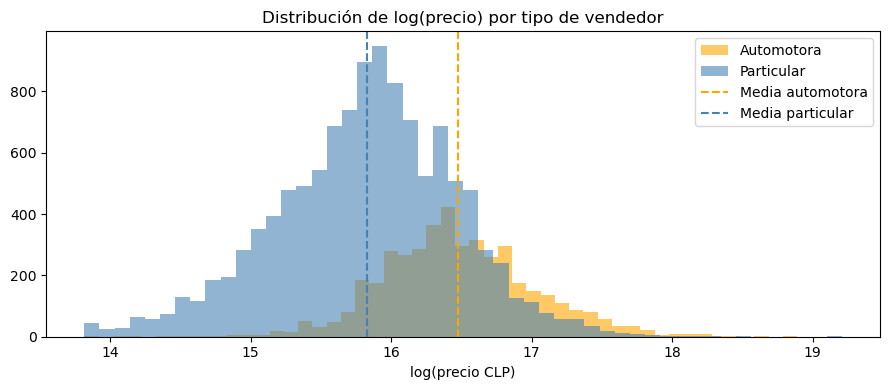

Diferencia cruda log-precio: 0.6507  ≈  91.7%
⚠️  Este número NO es el efecto causal. Está confundido por marca, año, km, etc.


In [7]:
# ── Celda 4: Distribución de log_precio por grupo ─────────────────
# DECISIÓN: usamos log(precio) como variable dependiente Y.
# Razón: los precios son log-normales (Rosen, 1974 — modelo hedónico).
# Un coeficiente en log → interpretación directa como % de premio/descuento.
import numpy as np

df["log_precio"] = np.log(df["precio_clp"])

fig, ax = plt.subplots(figsize=(9, 4))
for grupo, color in [(True, "orange"), (False, "steelblue")]:
    subset = df.loc[df["es_automotora"] == grupo, "log_precio"].dropna()
    ax.hist(subset, bins=50, alpha=0.6, color=color,
            label="Automotora" if grupo else "Particular")
ax.axvline(df.loc[df["es_automotora"]==True,  "log_precio"].mean(),
           color="orange", linestyle="--", label="Media automotora")
ax.axvline(df.loc[df["es_automotora"]==False, "log_precio"].mean(),
           color="steelblue", linestyle="--", label="Media particular")
ax.set_title("Distribución de log(precio) por tipo de vendedor")
ax.set_xlabel("log(precio CLP)"); ax.legend()
plt.tight_layout(); plt.show()

# Diferencia cruda (sin controlar confounders → NO es θ₀)
diff_cruda = (df.loc[df["es_automotora"]==True,  "log_precio"].mean() -
              df.loc[df["es_automotora"]==False, "log_precio"].mean())
print(f"Diferencia cruda log-precio: {diff_cruda:.4f}  ≈  {np.expm1(diff_cruda)*100:.1f}%")
print("⚠️  Este número NO es el efecto causal. Está confundido por marca, año, km, etc.")


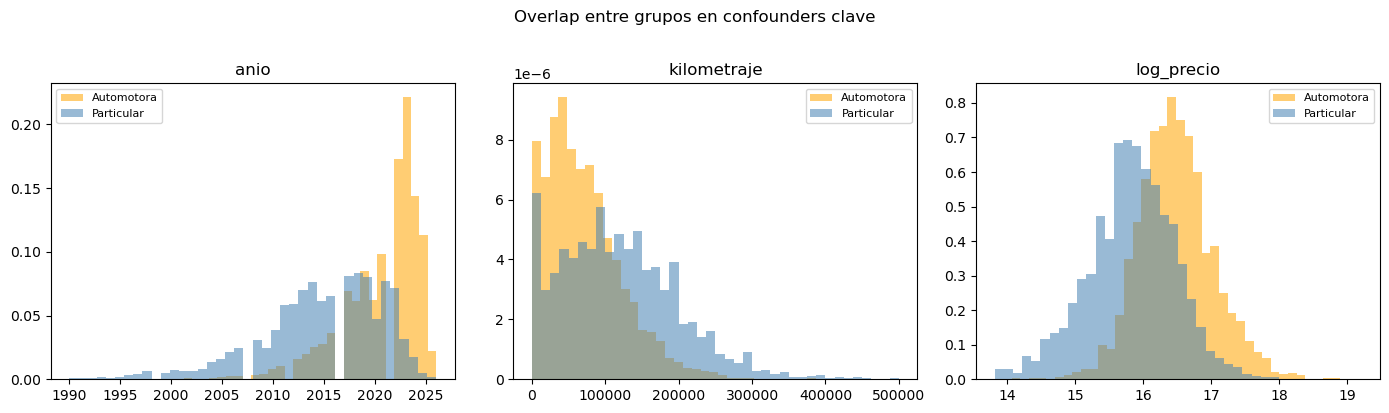

In [9]:
# ── Celda 5: Overlap en confounders principales ───────────────────
# DECISIÓN: verificar que ambos grupos compartan soporte en las
# variables más importantes. Si no → positivity violation.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["anio", "kilometraje", "log_precio"]):
    for grupo, color, lbl in [(True, "orange", "Automotora"),
                               (False, "steelblue", "Particular")]:
        vals = df.loc[df["es_automotora"] == grupo, col].dropna()
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=lbl,
                density=True)
    ax.set_title(col); ax.legend(fontsize=8)

plt.suptitle("Overlap entre grupos en confounders clave", y=1.02)
plt.tight_layout(); plt.show()


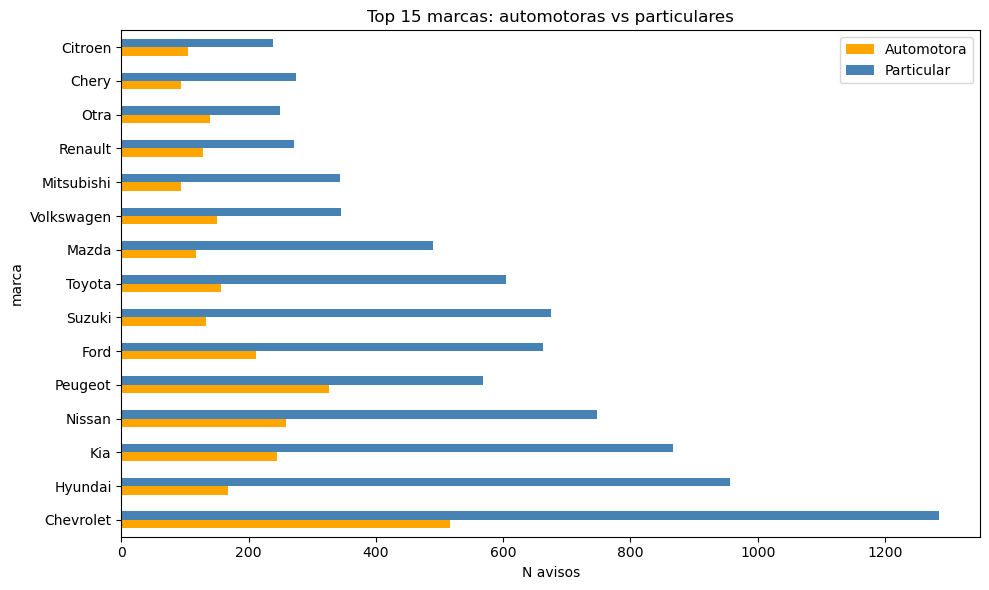

In [11]:
# ── Celda 6: CORREGIDA ─────────────────────────────────
top_marcas = (df.groupby(["marca", "es_automotora"])
                .size()
                .reset_index(name="n")
                .pivot(index="marca", columns="es_automotora", values="n")
                .fillna(0)
                # CAMBIO: Usamos 1 y 0 en lugar de True/False
                .assign(total=lambda x: x[1] + x[0]) 
                .nlargest(15, "total"))

# CAMBIO: Accedemos a las columnas por sus nombres numéricos [1, 0]
top_marcas[[1, 0]].plot(kind="barh", figsize=(10, 6),
                        color=["orange","steelblue"])

plt.legend(["Automotora", "Particular"]) # Agregamos leyenda para claridad
plt.title("Top 15 marcas: automotoras vs particulares")
plt.xlabel("N avisos"); plt.tight_layout(); plt.show()

In [12]:
# ── Celda 7: Conclusiones del EDA clean ───────────────────────────
# (llenar con los números reales que obtengas al correrlo)
print("""
RESUMEN EDA CLEAN
─────────────────
1. Observaciones finales: {n}
2. % automotoras: {pct_auto:.1f}%  → ¿hay positivity?
3. Diferencia cruda log-precio: {diff:.4f} ({pct_diff:.1f}%)
   → Esto MEZCLA efecto causal + diferencias de portafolio
4. Columnas con nulos residuales: (ver celda 2)
5. Overlap visual: (ver histogramas celda 5)
""".format(n=len(df),
           pct_auto=df["es_automotora"].mean()*100,
           diff=diff_cruda,
           pct_diff=np.expm1(diff_cruda)*100))



RESUMEN EDA CLEAN
─────────────────
1. Observaciones finales: 15860
2. % automotoras: 27.5%  → ¿hay positivity?
3. Diferencia cruda log-precio: 0.6507 (91.7%)
   → Esto MEZCLA efecto causal + diferencias de portafolio
4. Columnas con nulos residuales: (ver celda 2)
5. Overlap visual: (ver histogramas celda 5)



In [13]:
# ── GUARDAR es_automotora en el CSV clean ──────────────────────────
# DECISIÓN: persistir la variable de tratamiento en el CSV para que
# todos los notebooks siguientes la usen de forma reproducible.

df["es_automotora"] = (
    df["tipo_vendedor"].str.strip().str.lower() != "particular"
).astype(int)

# Verificación final antes de guardar
assert df["es_automotora"].isin([0, 1]).all(), "Hay valores inesperados"
print(f"Guardando {len(df)} filas con es_automotora: "
      f"{df['es_automotora'].mean()*100:.1f}% automotoras")

df.to_csv("../data/processed/yapo_clean.csv", index=False)
print("✅ yapo_clean.csv actualizado con es_automotora")


Guardando 15860 filas con es_automotora: 27.5% automotoras
✅ yapo_clean.csv actualizado con es_automotora
